# Country-by-country quarterly OLS/IV coefficients against shock-weighted $\xi$

This notebook runs separate time-series regressions for each country using quarterly data.

Configurable elements:

- `estimation_mode`: `"ols"` or `"iv"`
- `plot_horizons`: the CPI horizons to estimate and plot
- `y_lags = 3`
- `shock_lags = 3`
- optional lagged macro controls only, with 3 lags and no contemporaneous controls

For `h = 0`, the regression uses quarterly CPI on quarterly oil.
For `h > 0`, the regression uses cumulative CPI on cumulative oil, summing from `t` through `t+h` in the same spirit as the panel cumulative notebooks.
Lag terms remain lags of the underlying quarterly CPI and quarterly oil series.

For each country, the plot x-axis is the shock-weighted exposure measure

$$\tilde{\xi}_m = \frac{\sum_t \xi_{m,t} u_t^2}{\sum_t u_t^2}$$

where $u_t = \text{oil\_pct\_change}_t$, computed over that country's regression sample.

In IV mode, the contemporaneous and cumulative oil shocks are instrumented with the matching quarterly Kaenzig news shock series.


In [249]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [250]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
news_path = ROOT / "data/processed/oil/kaenzig_oil_supply_surprises_quarterly.csv"
news_column = "news_shock"

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    },
]

macro_controls = ["exchange_rate", "output_gap", "policy_rate"]
estimation_mode = "ols"  # "ols" or "iv"
exclude_countries = []
plot_horizons = [3]
y_lags = 3
shock_lags = 3
control_lags = 3
lag_xi_by_one_year_for_xi_x_oil = True
x_axis_metric = "xi"
y_axis_mode = "coef"  # "coef" or "coef_over_metric"
equality_alpha = 0.05
equality_test_mode = "metric"  # "metric" or "scaled_metric"
equality_test_constant = 1

XI_AXIS_OPTIONS = {
    "xi": {
        "panel_col": "xi",
        "result_col": "xi_weighted",
        "label": "Shock-weighted xi in the country regression sample",
    },
    "xi_amp1": {
        "panel_col": "xi_amp_1",
        "result_col": "xi_amp1_weighted",
        "label": "Shock-weighted xi_amp1 in the country regression sample",
    },
    "xi_amp2": {
        "panel_col": "xi_amp_2",
        "result_col": "xi_amp2_weighted",
        "label": "Shock-weighted xi_amp2 in the country regression sample",
    },
}

Y_AXIS_OPTIONS = {
    "coef": {
        "label": "Country-specific {mode_label} coefficient on shock",
    },
    "coef_over_metric": {
        "label": "Country-specific {mode_label} coefficient divided by shock-weighted metric",
    },
}

EQUALITY_TEST_OPTIONS = {"metric", "scaled_metric"}

if estimation_mode not in {"ols", "iv"}:
    raise ValueError("estimation_mode must be 'ols' or 'iv'")

if x_axis_metric not in XI_AXIS_OPTIONS:
    raise ValueError(f"x_axis_metric must be one of {sorted(XI_AXIS_OPTIONS)}")

if y_axis_mode not in Y_AXIS_OPTIONS:
    raise ValueError(f"y_axis_mode must be one of {sorted(Y_AXIS_OPTIONS)}")

if equality_test_mode not in EQUALITY_TEST_OPTIONS:
    raise ValueError(f"equality_test_mode must be one of {sorted(EQUALITY_TEST_OPTIONS)}")

panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    news_path=news_path,
    news_column=news_column,
    cpi_freq="Q",
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
)

print(f"Panel rows: {len(panel_df):,}")
print(f"Countries: {panel_df['country'].nunique()}")
print(f"Excluded countries: {exclude_countries}")
print(f"Periods: {panel_df['period'].nunique()}")
print(f"estimation_mode: {estimation_mode}")
print(f"Plot horizons: {plot_horizons}")
print(f"x_axis_metric: {x_axis_metric}")
print(f"y_axis_mode: {y_axis_mode}")
print(f"equality_test_mode: {equality_test_mode}")
print(f"equality_test_constant: {equality_test_constant}")
panel_df.head()


Panel rows: 7,522
Countries: 80
Excluded countries: []
Periods: 112
estimation_mode: ols
Plot horizons: [3]
x_axis_metric: xi
y_axis_mode: coef
equality_test_mode: metric
equality_test_constant: 1


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,xi_amp_1,xi_amp_2,xi_amp,news,xi_x_news,exchange_rate,output_gap,policy_rate
0,AGO,2002,2002-Q2,8009,0.085897,0.189848,0.007227,0.171750,0.010059,0.008580,0.018639,-0.452902,-0.017241,0.147258,0.002102,NaN
1,AGO,2002,2002-Q3,8010,0.085897,0.066242,0.002522,0.209522,0.010059,0.008580,0.018639,0.865002,0.032929,0.131988,0.021675,NaN
2,AGO,2002,2002-Q4,8011,0.085897,-0.011465,-0.000436,0.179419,0.010059,0.008580,0.018639,0.675704,0.025723,0.157769,0.062869,NaN
3,AGO,2003,2003-Q1,8012,0.107717,0.162677,0.013974,0.234092,0.016459,0.012144,0.028603,0.924390,0.079403,0.181845,-0.050575,NaN
4,AGO,2003,2003-Q2,8013,0.107717,-0.167036,-0.014348,0.200532,0.016459,0.012144,0.028603,-0.782905,-0.067250,0.131072,-0.056534,NaN


In [251]:
def build_country_regression_sample(
    country_df: pd.DataFrame,
    *,
    horizon: int,
    macro_controls: list[str],
    include_lagged_controls: bool,
    estimation_mode: str,
) -> tuple[pd.DataFrame, str, str, str | None, list[str], list[str]]:
    if horizon < 0:
        raise ValueError("horizon must be >= 0")

    work = country_df[[
        "country",
        "period",
        "time_index",
        "year",
        "xi",
        "xi_amp_1",
        "xi_amp_2",
        "cpi_pct_change",
        "oil_pct_change",
        "news",
        *macro_controls,
    ]].copy()
    work = work.sort_values("time_index").reset_index(drop=True)

    if horizon == 0:
        dep_col = "cpi_pct_change_h0"
        shock_col = "oil_pct_change_h0"
        instrument_col = "news_h0" if estimation_mode == "iv" else None
        work[dep_col] = work["cpi_pct_change"]
        work[shock_col] = work["oil_pct_change"]
        if instrument_col is not None:
            work[instrument_col] = work["news"]
    else:
        dep_col = f"cum_cpi_lead{horizon}"
        shock_col = f"cum_oil_lead{horizon}"
        instrument_col = f"cum_news_lead{horizon}" if estimation_mode == "iv" else None
        work[dep_col] = 0.0
        work[shock_col] = 0.0
        if instrument_col is not None:
            work[instrument_col] = 0.0
        for step in range(horizon + 1):
            shifted_cpi = work["cpi_pct_change"].shift(-step)
            shifted_oil = work["oil_pct_change"].shift(-step)
            shifted_news = work["news"].shift(-step)
            work[dep_col] = shifted_cpi if step == 0 else work[dep_col] + shifted_cpi
            work[shock_col] = shifted_oil if step == 0 else work[shock_col] + shifted_oil
            if instrument_col is not None:
                work[instrument_col] = shifted_news if step == 0 else work[instrument_col] + shifted_news

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"cpi_pct_change_lag{lag}"
        work[col] = work["cpi_pct_change"].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    instrument_lag_cols = []
    for lag in range(1, shock_lags + 1):
        shock_lag_col = f"oil_pct_change_lag{lag}"
        work[shock_lag_col] = work["oil_pct_change"].shift(lag)
        shock_lag_cols.append(shock_lag_col)
        if estimation_mode == "iv":
            instrument_lag_col = f"news_lag{lag}"
            work[instrument_lag_col] = work["news"].shift(lag)
            instrument_lag_cols.append(instrument_lag_col)

    control_cols = []
    if include_lagged_controls:
        for control in macro_controls:
            for lag in range(1, control_lags + 1):
                col = f"{control}_lag{lag}"
                work[col] = work[control].shift(lag)
                control_cols.append(col)

    x_cols = [shock_col, *shock_lag_cols, *y_lag_cols]
    z_cols = [instrument_col, *instrument_lag_cols, *y_lag_cols] if estimation_mode == "iv" else []
    if include_lagged_controls:
        x_cols.extend(control_cols)
        if estimation_mode == "iv":
            z_cols.extend(control_cols)

    required_cols = [dep_col, *x_cols]
    if estimation_mode == "iv":
        required_cols.extend(z_cols)

    work = work.dropna(subset=required_cols).copy()
    return work, dep_col, shock_col, instrument_col, x_cols, z_cols


def compute_shock_weighted_metric(work: pd.DataFrame, metric_col: str) -> float:
    weights = work["oil_pct_change"].astype(float) ** 2
    denom = float(weights.sum())
    if denom == 0.0:
        return float("nan")
    return float((work[metric_col].astype(float) * weights).sum() / denom)


def has_full_column_rank(matrix: pd.DataFrame) -> bool:
    values = np.asarray(matrix, dtype=float)
    if values.ndim != 2 or values.size == 0:
        return False
    return int(np.linalg.matrix_rank(values)) == int(values.shape[1])


def run_country_regression(
    df: pd.DataFrame,
    *,
    horizon: int,
    include_lagged_controls: bool,
    estimation_mode: str,
) -> pd.DataFrame:
    rows = []

    for country, country_df in df.groupby("country"):
        work, dep_col, shock_col, instrument_col, x_cols, z_cols = build_country_regression_sample(
            country_df,
            horizon=horizon,
            macro_controls=macro_controls,
            include_lagged_controls=include_lagged_controls,
            estimation_mode=estimation_mode,
        )
        min_required_obs = len(z_cols) if estimation_mode == "iv" else len(x_cols)
        if work.empty or len(work) <= min_required_obs:
            continue

        y = pd.to_numeric(work[dep_col], errors="coerce")
        x = sm.add_constant(work[x_cols], has_constant="add")
        if not has_full_column_rank(x):
            continue
        if estimation_mode == "iv":
            z = sm.add_constant(work[z_cols], has_constant="add")
            if not has_full_column_rank(z):
                continue
            if not has_full_column_rank(pd.concat([x, z], axis=1)):
                continue
            try:
                model = IV2SLS(y, x, z).fit()
            except np.linalg.LinAlgError:
                continue
            first_stage = sm.OLS(work[shock_col], z, missing="raise").fit()
            first_stage_coef = float(first_stage.params[instrument_col])
            first_stage_t = float(first_stage.tvalues[instrument_col])
            first_stage_p = float(first_stage.pvalues[instrument_col])
        else:
            try:
                model = sm.OLS(y, x, missing="raise").fit()
            except np.linalg.LinAlgError:
                continue
            first_stage_coef = float("nan")
            first_stage_t = float("nan")
            first_stage_p = float("nan")

        shock_se = float(model.bse[shock_col])
        shock_ci = model.conf_int(alpha=equality_alpha).loc[shock_col]
        weight_inv_var = float(1.0 / (shock_se ** 2)) if shock_se > 0 else float("nan")

        row = {
            "country": country,
            "horizon": horizon,
            "nobs": int(model.nobs),
            "estimation_mode": estimation_mode,
            "shock_col": shock_col,
            "instrument_col": instrument_col,
            "coef_shock": float(model.params[shock_col]),
            "se_shock": shock_se,
            "shock_ci_low": float(shock_ci.iloc[0]),
            "shock_ci_high": float(shock_ci.iloc[1]),
            "t_shock": float(model.tvalues[shock_col]),
            "p_shock": float(model.pvalues[shock_col]),
            "r2": float(getattr(model, "rsquared", float("nan"))),
            "include_lagged_controls": include_lagged_controls,
            "n_regressors_ex_const": len(x_cols),
            "weight_inv_var": weight_inv_var,
            "first_stage_coef": first_stage_coef,
            "first_stage_t": first_stage_t,
            "first_stage_p": first_stage_p,
        }
        for metric_name, metric_spec in XI_AXIS_OPTIONS.items():
            row[metric_spec["result_col"]] = compute_shock_weighted_metric(work, metric_spec["panel_col"])
        rows.append(row)

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["horizon", "country"]).reset_index(drop=True)


def run_spec_for_horizons(
    df: pd.DataFrame,
    *,
    horizons: list[int],
    include_lagged_controls: bool,
    estimation_mode: str,
) -> pd.DataFrame:
    parts = []
    for horizon in horizons:
        result = run_country_regression(
            df,
            horizon=horizon,
            include_lagged_controls=include_lagged_controls,
            estimation_mode=estimation_mode,
        )
        parts.append(result)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, axis=0, ignore_index=True)


def build_equality_reference_columns(
    results: pd.DataFrame,
    *,
    metric_col: str,
    equality_test_mode: str = equality_test_mode,
    equality_test_constant: float = equality_test_constant,
) -> tuple[pd.DataFrame, str, float]:
    if equality_test_mode == "metric":
        equality_multiplier = 1.0
        equality_reference_label = "weighted metric"
    elif equality_test_mode == "scaled_metric":
        equality_multiplier = float(equality_test_constant)
        equality_reference_label = f"{equality_multiplier:g} * weighted metric"
    else:
        raise ValueError(f"Unsupported equality_test_mode: {equality_test_mode}")

    annotated = results.copy()
    annotated["equality_reference"] = equality_multiplier * annotated[metric_col]
    annotated["non_reject_metric_equality"] = (
        annotated["equality_reference"].notna()
        & annotated["shock_ci_low"].notna()
        & annotated["shock_ci_high"].notna()
        & (annotated["equality_reference"] >= annotated["shock_ci_low"])
        & (annotated["equality_reference"] <= annotated["shock_ci_high"])
    )
    return annotated, equality_reference_label, equality_multiplier


def plot_coef_vs_weighted_xi(
    results: pd.DataFrame,
    *,
    title_prefix: str,
    x_axis_metric: str = x_axis_metric,
    y_axis_mode: str = y_axis_mode,
) -> None:
    metric_spec = XI_AXIS_OPTIONS[x_axis_metric]
    metric_col = metric_spec["result_col"]
    y_axis_spec = Y_AXIS_OPTIONS[y_axis_mode]

    for horizon in sorted(results["horizon"].unique()):
        horizon_df = results.loc[results["horizon"] == horizon].copy()
        horizon_df = horizon_df.dropna(
            subset=[metric_col, "coef_shock", "se_shock", "weight_inv_var", "shock_ci_low", "shock_ci_high"]
        ).copy()
        if y_axis_mode == "coef_over_metric":
            horizon_df = horizon_df.loc[horizon_df[metric_col] != 0].copy()
        if horizon_df.empty:
            continue

        horizon_df, equality_reference_label, equality_multiplier = build_equality_reference_columns(
            horizon_df,
            metric_col=metric_col,
        )
        if y_axis_mode == "coef_over_metric":
            horizon_df["y_value"] = horizon_df["coef_shock"] / horizon_df[metric_col]
            y_line_ref = equality_multiplier
        else:
            horizon_df["y_value"] = horizon_df["coef_shock"]
            y_line_ref = 0.0

        fig, ax = plt.subplots(figsize=(10, 7))
        marker_sizes = 40.0 * horizon_df["weight_inv_var"] / horizon_df["weight_inv_var"].median()
        point_colors = np.where(horizon_df["non_reject_metric_equality"], "#1b9e77", "#7f7f7f")
        ax.scatter(
            horizon_df[metric_col],
            horizon_df["y_value"],
            s=marker_sizes,
            c=point_colors,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.6,
        )

        for row in horizon_df.itertuples(index=False):
            label_color = "#1b9e77" if row.non_reject_metric_equality else "#4d4d4d"
            ax.annotate(
                row.country,
                (getattr(row, metric_col), row.y_value),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                color=label_color,
            )

        fit = sm.WLS(
            horizon_df["y_value"],
            sm.add_constant(horizon_df[metric_col], has_constant="add"),
            weights=horizon_df["weight_inv_var"],
        ).fit()
        x_line = pd.Series(sorted(horizon_df[metric_col]))
        x_line_design = sm.add_constant(x_line, has_constant="add")
        prediction = fit.get_prediction(x_line_design).summary_frame(alpha=0.05)
        y_line = prediction["mean"]
        ci_lower = prediction["mean_ci_lower"]
        ci_upper = prediction["mean_ci_upper"]
        ax.plot(x_line, y_line, color="black", linewidth=1.5, linestyle="--")
        ax.fill_between(x_line, ci_lower, ci_upper, color="black", alpha=0.12)
        equation = f"WLS fit: y = {fit.params['const']:.3f} + {fit.params.iloc[1]:.3f} x"

        ax.axhline(y_line_ref, color="0.6", linewidth=1.0)
        y_min = float(horizon_df["y_value"].min())
        y_max = float(horizon_df["y_value"].max())
        y_span = y_max - y_min
        y_pad = 0.08 * y_span if y_span > 0 else max(abs(y_min), 1.0) * 0.08
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_xlabel(metric_spec["label"])
        shock_label = horizon_df["shock_col"].iloc[0]
        mode_label = str(horizon_df["estimation_mode"].iloc[0]).upper()
        ax.set_ylabel(y_axis_spec["label"].format(mode_label=mode_label))
        ax.set_title(
            f"{title_prefix}, mode={mode_label}, horizon={horizon}, shock={shock_label}, x={x_axis_metric}, y={y_axis_mode}"
        )
        ax.text(
            0.02,
            0.98,
            equation,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
        )
        ax.text(
            0.02,
            0.90,
            f"Green: cannot reject coefficient = {equality_reference_label} at {100 * (1 - equality_alpha):.0f}%",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
        )
        ax.grid(alpha=0.25)
        plt.show()


## Spec 1: No Controls


In [252]:
results_spec1 = run_spec_for_horizons(
    panel_df,
    horizons=plot_horizons,
    include_lagged_controls=False,
    estimation_mode=estimation_mode,
)
print(f"Rows estimated: {len(results_spec1)}")
results_spec1.head()


Rows estimated: 80


,country,horizon,nobs,estimation_mode,shock_col,instrument_col,coef_shock,se_shock,shock_ci_low,shock_ci_high,...,r2,include_lagged_controls,n_regressors_ex_const,weight_inv_var,first_stage_coef,first_stage_t,first_stage_p,xi_weighted,xi_amp1_weighted,xi_amp2_weighted
0,AGO,3,77,ols,cum_oil_lead3,None,-0.012321,0.018710,-0.049647,0.025005,...,0.734904,False,7,2856.510463,NaN,NaN,NaN,0.094848,0.025652,0.017160
1,ARE,3,53,ols,cum_oil_lead3,None,0.011515,0.008646,-0.005898,0.028928,...,0.151526,False,7,13378.758164,NaN,NaN,NaN,0.107245,0.020237,0.015815
2,ARG,3,17,ols,cum_oil_lead3,None,0.076178,0.054765,-0.047708,0.200065,...,0.532119,False,7,333.422304,NaN,NaN,NaN,0.062012,0.016989,0.021123
3,AUS,3,106,ols,cum_oil_lead3,None,0.020717,0.003447,0.013877,0.027558,...,0.348620,False,7,84155.467837,NaN,NaN,NaN,0.027082,0.007802,0.012143
4,AUT,3,106,ols,cum_oil_lead3,None,0.020333,0.003566,0.013257,0.027409,...,0.366346,False,7,78655.319180,NaN,NaN,NaN,0.028237,0.009198,0.016730


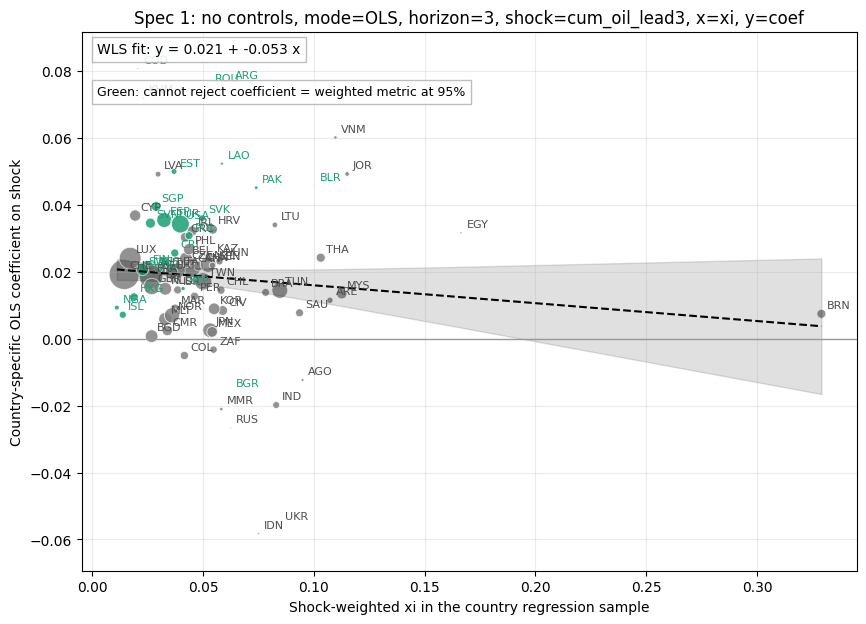

In [253]:
plot_coef_vs_weighted_xi(results_spec1, title_prefix="Spec 1: no controls", x_axis_metric=x_axis_metric, y_axis_mode=y_axis_mode)


## Spec 2: Lagged Macro Controls Only


In [254]:
results_spec2 = run_spec_for_horizons(
    panel_df,
    horizons=plot_horizons,
    include_lagged_controls=True,
    estimation_mode=estimation_mode,
)
print(f"Rows estimated: {len(results_spec2)}")
results_spec2.head()


c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


Rows estimated: 48


,country,horizon,nobs,estimation_mode,shock_col,instrument_col,coef_shock,se_shock,shock_ci_low,shock_ci_high,...,r2,include_lagged_controls,n_regressors_ex_const,weight_inv_var,first_stage_coef,first_stage_t,first_stage_p,xi_weighted,xi_amp1_weighted,xi_amp2_weighted
0,ARG,3,17,ols,cum_oil_lead3,None,-0.468044,inf,NaN,NaN,...,1.000000,True,16,0.000000,NaN,NaN,NaN,0.062012,0.016989,0.021123
1,AUS,3,106,ols,cum_oil_lead3,None,0.024041,0.003543,0.017001,0.031081,...,0.464982,True,16,79654.959014,NaN,NaN,NaN,0.027082,0.007802,0.012143
2,AUT,3,90,ols,cum_oil_lead3,None,0.019853,0.004446,0.010992,0.028714,...,0.550159,True,16,50589.278375,NaN,NaN,NaN,0.029305,0.009424,0.017644
3,BEL,3,90,ols,cum_oil_lead3,None,0.026456,0.005618,0.015260,0.037652,...,0.532364,True,16,31687.539686,NaN,NaN,NaN,0.043073,0.010204,0.017341
4,BRA,3,102,ols,cum_oil_lead3,None,0.025159,0.009164,0.006938,0.043379,...,0.330124,True,16,11907.979113,NaN,NaN,NaN,0.078143,0.021416,0.025441


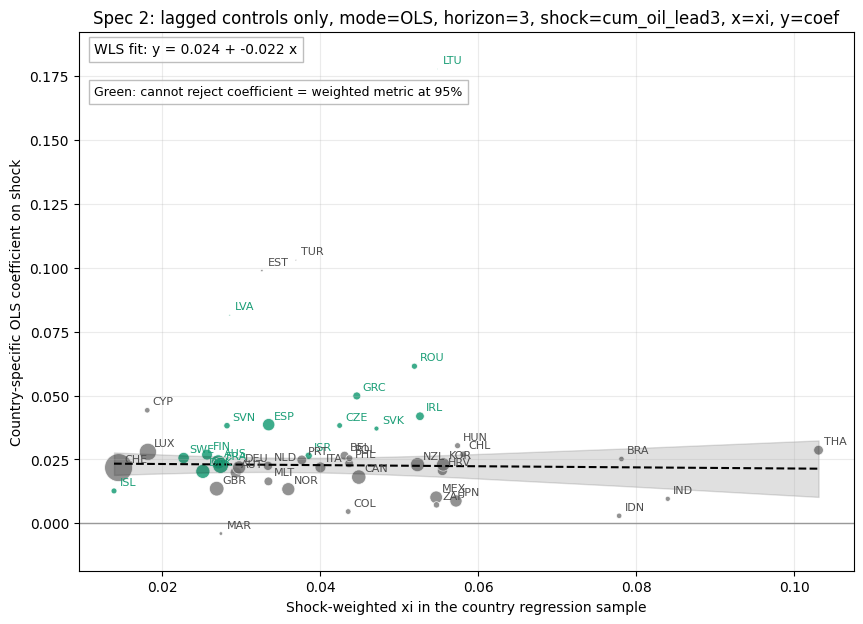

In [255]:
plot_coef_vs_weighted_xi(results_spec2, title_prefix="Spec 2: lagged controls only", x_axis_metric=x_axis_metric, y_axis_mode=y_axis_mode)


## Comparison Table


In [256]:
comparison_df = (
    results_spec1[["country", "horizon", "shock_col", "coef_shock", "se_shock", "weight_inv_var", "nobs", "xi_weighted", "xi_amp1_weighted", "xi_amp2_weighted"]]
    .rename(columns={
        "shock_col": "shock_col_spec1",
        "coef_shock": "coef_spec1",
        "se_shock": "se_spec1",
        "weight_inv_var": "weight_spec1",
        "nobs": "nobs_spec1",
        "xi_weighted": "xi_weighted_spec1",
        "xi_amp1_weighted": "xi_amp1_weighted_spec1",
        "xi_amp2_weighted": "xi_amp2_weighted_spec1",
    })
    .merge(
        results_spec2[["country", "horizon", "shock_col", "coef_shock", "se_shock", "weight_inv_var", "nobs", "xi_weighted", "xi_amp1_weighted", "xi_amp2_weighted"]].rename(columns={
            "shock_col": "shock_col_spec2",
            "coef_shock": "coef_spec2",
            "se_shock": "se_spec2",
            "weight_inv_var": "weight_spec2",
            "nobs": "nobs_spec2",
            "xi_weighted": "xi_weighted_spec2",
            "xi_amp1_weighted": "xi_amp1_weighted_spec2",
            "xi_amp2_weighted": "xi_amp2_weighted_spec2",
        }),
        on=["country", "horizon"],
        how="outer",
    )
    .sort_values(["horizon", "country"])
    .reset_index(drop=True)
)

comparison_df.head(20)


,country,horizon,shock_col_spec1,coef_spec1,se_spec1,weight_spec1,nobs_spec1,xi_weighted_spec1,xi_amp1_weighted_spec1,xi_amp2_weighted_spec1,shock_col_spec2,coef_spec2,se_spec2,weight_spec2,nobs_spec2,xi_weighted_spec2,xi_amp1_weighted_spec2,xi_amp2_weighted_spec2
0,AGO,3,cum_oil_lead3,-0.012321,0.018710,2856.510463,77,0.094848,0.025652,0.017160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ARE,3,cum_oil_lead3,0.011515,0.008646,13378.758164,53,0.107245,0.020237,0.015815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ARG,3,cum_oil_lead3,0.076178,0.054765,333.422304,17,0.062012,0.016989,0.021123,cum_oil_lead3,-0.468044,inf,0.000000,17.0,0.062012,0.016989,0.021123
3,AUS,3,cum_oil_lead3,0.020717,0.003447,84155.467837,106,0.027082,0.007802,0.012143,cum_oil_lead3,0.024041,0.003543,79654.959014,106.0,0.027082,0.007802,0.012143
4,AUT,3,cum_oil_lead3,0.020333,0.003566,78655.319180,106,0.028237,0.009198,0.016730,cum_oil_lead3,0.019853,0.004446,50589.278375,90.0,0.029305,0.009424,0.017644
5,BEL,3,cum_oil_lead3,0.023971,0.004133,58553.674406,106,0.042269,0.010204,0.016961,cum_oil_lead3,0.026456,0.005618,31687.539686,90.0,0.043073,0.010204,0.017341
6,BGD,3,cum_oil_lead3,0.000801,0.004197,56764.086132,45,0.026772,0.010767,0.011472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,BGR,3,cum_oil_lead3,-0.016030,0.283498,12.442300,105,0.062392,0.023352,0.027487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,BLR,3,cum_oil_lead3,0.045725,0.049689,405.015619,65,0.099976,0.044498,0.042077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,BRA,3,cum_oil_lead3,0.013872,0.006855,21282.044748,106,0.078220,0.021444,0.025421,cum_oil_lead3,0.025159,0.009164,11907.979113,102.0,0.078143,0.021416,0.025441


In [257]:
metric_col = XI_AXIS_OPTIONS[x_axis_metric]["result_col"]

def summarize_green_countries(results: pd.DataFrame, spec_label: str) -> pd.DataFrame:
    summary, equality_reference_label, _ = build_equality_reference_columns(results, metric_col=metric_col)
    summary = summary.dropna(subset=[metric_col, "equality_reference", "shock_ci_low", "shock_ci_high"]).copy()
    return (
        summary.groupby("horizon", as_index=False)
        .agg(
            green_countries=("non_reject_metric_equality", "sum"),
            total_countries=("country", "count"),
        )
        .assign(
            spec=spec_label,
            equality_reference=equality_reference_label,
            share_green=lambda df: df["green_countries"] / df["total_countries"],
        )
        [["spec", "horizon", "equality_reference", "green_countries", "total_countries", "share_green"]]
    )

green_country_summary = pd.concat(
    [
        summarize_green_countries(results_spec1, "Spec 1: no controls"),
        summarize_green_countries(results_spec2, "Spec 2: lagged controls only"),
    ],
    ignore_index=True,
)

green_country_summary


,spec,horizon,equality_reference,green_countries,total_countries,share_green
0,Spec 1: no controls,3,weighted metric,24,80,0.300000
1,Spec 2: lagged controls only,3,weighted metric,16,47,0.340426


In [258]:
def list_green_countries(results: pd.DataFrame, spec_label: str) -> pd.DataFrame:
    summary, equality_reference_label, _ = build_equality_reference_columns(results, metric_col=metric_col)
    summary = summary.dropna(subset=[metric_col, "equality_reference", "shock_ci_low", "shock_ci_high"])
    summary = summary.loc[summary["non_reject_metric_equality"]].copy()
    return (
        summary.groupby("horizon", as_index=False)
        .agg(green_countries_list=("country", lambda s: ", ".join(sorted(s))))
        .assign(spec=spec_label, equality_reference=equality_reference_label)
        [["spec", "horizon", "equality_reference", "green_countries_list"]]
    )

green_country_list = pd.concat(
    [
        list_green_countries(results_spec1, "Spec 1: no controls"),
        list_green_countries(results_spec2, "Spec 2: lagged controls only"),
    ],
    ignore_index=True,
)

green_country_list


,spec,horizon,equality_reference,green_countries_list
0,Spec 1: no controls,3,weighted metric,"ARG, AUS, BGR, BLR, COD, CRI, DNK, ESP, EST, F..."
1,Spec 2: lagged controls only,3,weighted metric,"AUS, CZE, DNK, ESP, FIN, FRA, GRC, IRL, ISL, I..."


In [259]:
results_spec2_with_equality, spec2_equality_reference_label, _ = build_equality_reference_columns(
    results_spec2,
    metric_col=metric_col,
)

spec2_h3_green_countries = sorted(
    results_spec2_with_equality.loc[
        (results_spec2_with_equality["horizon"] == 3)
        & results_spec2_with_equality["non_reject_metric_equality"],
        "country",
    ].tolist()
)

spec2_h3_green_countries


['AUS',
 'CZE',
 'DNK',
 'ESP',
 'FIN',
 'FRA',
 'GRC',
 'IRL',
 'ISL',
 'ISR',
 'LTU',
 'LVA',
 'ROU',
 'SVK',
 'SVN',
 'SWE']

In [260]:
spec2_h3_all_countries = sorted(
    results_spec2.loc[
        results_spec2["horizon"] == 3,
        "country",
    ].dropna().tolist()
)

spec2_h3_all_countries


['ARG',
 'AUS',
 'AUT',
 'BEL',
 'BRA',
 'CAN',
 'CHE',
 'CHL',
 'COL',
 'CYP',
 'CZE',
 'DEU',
 'DNK',
 'ESP',
 'EST',
 'FIN',
 'FRA',
 'GBR',
 'GRC',
 'HRV',
 'HUN',
 'IDN',
 'IND',
 'IRL',
 'ISL',
 'ISR',
 'ITA',
 'JPN',
 'KOR',
 'LTU',
 'LUX',
 'LVA',
 'MAR',
 'MEX',
 'MLT',
 'NLD',
 'NOR',
 'NZL',
 'PHL',
 'POL',
 'PRT',
 'ROU',
 'SVK',
 'SVN',
 'SWE',
 'THA',
 'TUR',
 'ZAF']